In [1]:
# ============================================================
#   Auto‑Encoder Similarity Notebook for One Shape Folder
# ============================================================

# 0️⃣ Install / import packages (versions pinned for Colab)
!pip install -q "tensorflow==2.18.0" "pandas==2.1.4" "plotly>=5.19.0,<6" pillow scikit-learn

import os, io, base64, random, math
from pathlib import Path

import numpy as np
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
from sklearn.decomposition import PCA
from IPython.display import HTML, display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
xarray 2025.7.1 requires pandas>=2.2, but you have pandas 2.1.4 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.


In [11]:
#@title 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#@title 2️⃣ User settings — choose ONE shape folder & training params
SHAPES_ROOT = "/content/drive/MyDrive/shapes"  # <‑‑ adjust if needed

shape_folder   = "shape3"   #@param ["shape3","shape4","shape5","shape6"]
batch_size     = 32         #@param {type:"integer"}
epochs         = 40         #@param {type:"integer"}
plot_latent_2D = True       #@param {type:"boolean"}

shape_path = Path(SHAPES_ROOT) / shape_folder
assert shape_path.is_dir(), f"{shape_path} not found"

print(f"▶ Using folder: {shape_path}")


▶ Using folder: /content/drive/MyDrive/shapes/shape3


In [13]:
#@title 3️⃣ Load images (200×200 grayscale, no resizing, invert pixels)
def load_png(path):
    img = Image.open(path).convert("L")                 # grayscale
    arr = 1.0 - (np.array(img, dtype=np.float32) / 255) # invert: stroke→0
    return arr[..., None]                               # add channels dim

all_pngs = sorted([p for p in shape_path.iterdir() if p.suffix.lower()==".png"])
assert all_pngs, "No PNG images found."

ref_name = f"original{shape_folder[-1]}.png"
ref_path = shape_path / ref_name
assert ref_path.exists(), f"{ref_name} missing"
drawing_paths = [p for p in all_pngs if p.name != ref_name]

print(f"▶ Loaded {len(drawing_paths)} drawings (+1 reference)")

ref_img = load_png(ref_path)
x_imgs  = np.stack([load_png(p) for p in drawing_paths], axis=0)
print("Tensor shape:", x_imgs.shape)

▶ Loaded 897 drawings (+1 reference)
Tensor shape: (897, 200, 200, 1)


In [14]:
#@title 4️⃣ Define & compile convolution‑only auto‑encoder (binary‑Xent loss)
inp = layers.Input(shape=(200,200,1))

# --- Encoder (no Flatten/Dense) ---
x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
x = layers.MaxPool2D()(x)            # 100×100
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPool2D()(x)            # 50×50
latent = layers.Conv2D(128, 3, activation="relu", padding="same", name="latent")(x)
encoder = models.Model(inp, latent, name="encoder")

# --- Decoder ---
dec_in = layers.Input(shape=(50,50,128))
y = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(dec_in)  # 100×100
y = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(y)       # 200×200
out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(y)
decoder = models.Model(dec_in, out, name="decoder")

auto = models.Model(encoder.input, decoder(encoder.output), name="autoencoder")
auto.compile(optimizer="adam", loss="binary_crossentropy")

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Conv2D)                 │ (None, 50, 50, 128)    │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#@title 5️⃣ Train auto‑encoder
history = auto.fit(
    x_imgs, x_imgs,
    epochs   = epochs,
    batch_size = batch_size,
    shuffle  = True,
    validation_split = 0.1,
    verbose = 2
)


Epoch 1/40
26/26 - 5s - 208ms/step - loss: 0.2939 - val_loss: 0.1384
Epoch 2/40
26/26 - 0s - 18ms/step - loss: 0.1106 - val_loss: 0.0631
Epoch 3/40
26/26 - 0s - 18ms/step - loss: 0.0467 - val_loss: 0.0409
Epoch 4/40
26/26 - 0s - 18ms/step - loss: 0.0366 - val_loss: 0.0323
Epoch 5/40
26/26 - 0s - 18ms/step - loss: 0.0293 - val_loss: 0.0280
Epoch 6/40
26/26 - 0s - 18ms/step - loss: 0.0261 - val_loss: 0.0261
Epoch 7/40
26/26 - 0s - 18ms/step - loss: 0.0241 - val_loss: 0.0247
Epoch 8/40
26/26 - 0s - 18ms/step - loss: 0.0224 - val_loss: 0.0224
Epoch 9/40
26/26 - 0s - 18ms/step - loss: 0.0211 - val_loss: 0.0215
Epoch 10/40
26/26 - 0s - 18ms/step - loss: 0.0203 - val_loss: 0.0208
Epoch 11/40
26/26 - 0s - 18ms/step - loss: 0.0197 - val_loss: 0.0203
Epoch 12/40
26/26 - 0s - 18ms/step - loss: 0.0192 - val_loss: 0.0198
Epoch 13/40
26/26 - 0s - 18ms/step - loss: 0.0187 - val_loss: 0.0194
Epoch 14/40
26/26 - 0s - 18ms/step - loss: 0.0184 - val_loss: 0.0190
Epoch 15/40
26/26 - 0s - 18ms/step - loss:

In [16]:
#@title 6️⃣ Embed drawings & compute distances to reference
# flatten the 3‑D latent feature maps before measuring Euclidean distance
latent_ref   = encoder(np.expand_dims(ref_img,0)).numpy().reshape(-1)
latent_draws = encoder.predict(x_imgs, batch_size=batch_size).reshape(len(x_imgs), -1)
dists = np.linalg.norm(latent_draws - latent_ref, axis=1)

order         = np.argsort(dists)
sorted_paths  = [drawing_paths[i] for i in order]
sorted_dists  = dists[order]

print("Closest 5 drawings:")
for p, d in zip(sorted_paths[:5], sorted_dists[:5]):
    print(f"{p.name:>15} : dist={d:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Closest 5 drawings:
      10919.png : dist=136.2671
      10317.png : dist=140.6238
      10027.png : dist=146.9458
      10300.png : dist=149.8186
      10367.png : dist=156.1425


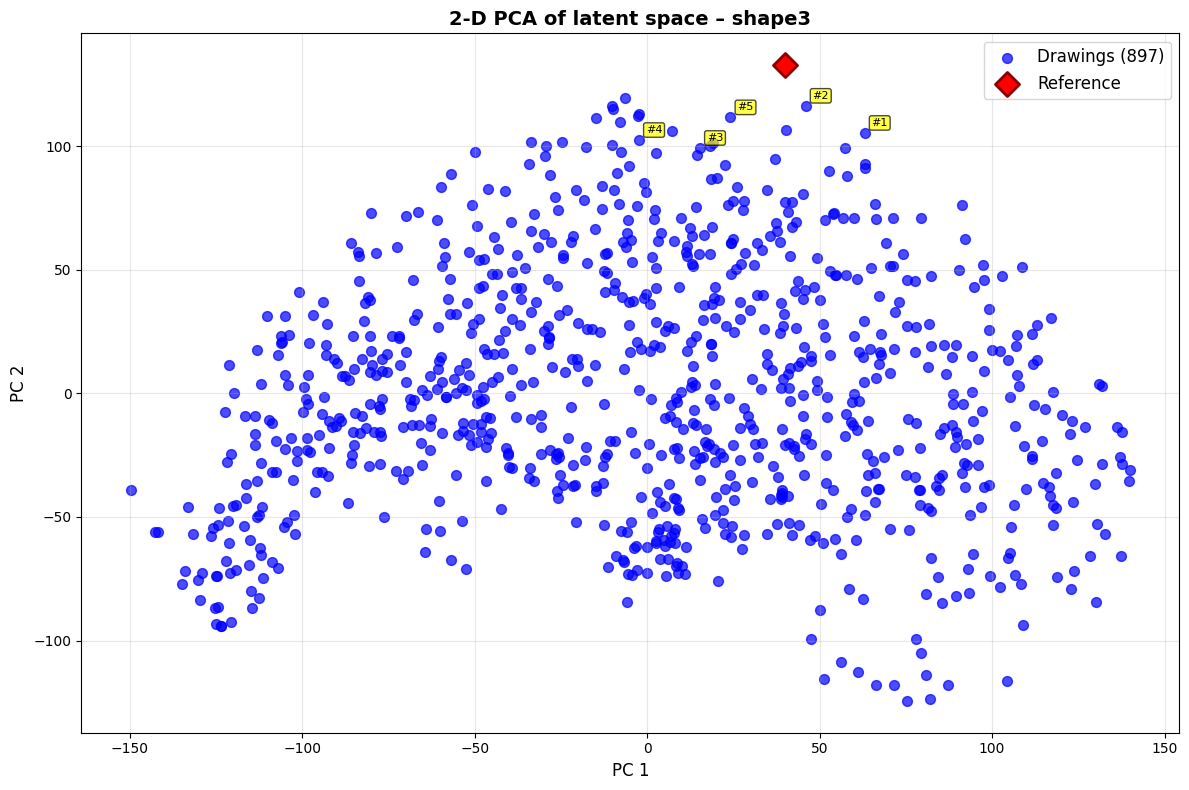

🖼️ IMAGE BROWSER:
Reference Image:


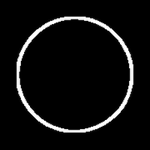


🎯 Top 10 Most Similar Drawings (out of 897):

#1: 10919.png (Distance: 136.2671)


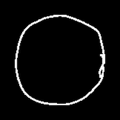


#2: 10317.png (Distance: 140.6238)


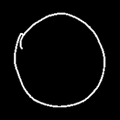


#3: 10027.png (Distance: 146.9458)


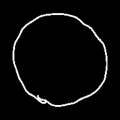


#4: 10300.png (Distance: 149.8186)


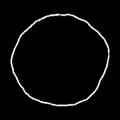


#5: 10367.png (Distance: 156.1425)


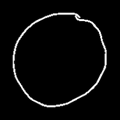


#6: 10511.png (Distance: 158.3055)


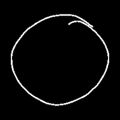


#7: 10954.png (Distance: 161.8029)


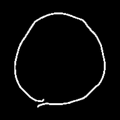


#8: 10956.png (Distance: 167.0367)


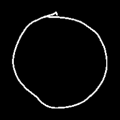


#9: 10543.png (Distance: 167.1678)


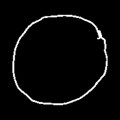


#10: 10011.png (Distance: 172.7190)


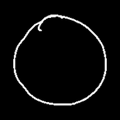


📈 SIMILARITY STATISTICS:
Mean distance: 270.3724
Std distance: 35.3237
Min distance: 136.2671
Max distance: 359.0044
Median distance: 273.4936


In [34]:
# Simple matplotlib version (always works in Colab)
if plot_latent_2D:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from IPython.display import display

    # ---------- reduce to 2‑D ----------
    all_lat = np.vstack([latent_ref.reshape(1, -1), latent_draws])
    lat2    = PCA(n_components=2).fit_transform(all_lat)
    xs, ys  = lat2[:, 0], lat2[:, 1]

    # Create matplotlib plot
    plt.figure(figsize=(12, 8))

    # Plot drawings
    plt.scatter(xs[1:], ys[1:], c='blue', s=50, alpha=0.7, label=f'Drawings ({len(drawing_paths)})')

    # Plot reference
    plt.scatter(xs[0], ys[0], c='red', s=150, marker='D', label='Reference', edgecolors='darkred', linewidth=2)

    # Customize plot
    plt.xlabel('PC 1', fontsize=12)
    plt.ylabel('PC 2', fontsize=12)
    plt.title(f'2-D PCA of latent space – {shape_folder}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add some annotations for closest points
    closest_indices = np.argsort(dists)[:5]
    for i, idx in enumerate(closest_indices):
        plt.annotate(f'#{i+1}',
                    (xs[idx+1], ys[idx+1]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # Create a simple image browser
    print("🖼️ IMAGE BROWSER:")
    print("Reference Image:")
    ref_img_pil = Image.open(ref_path).convert("RGB").resize((150, 150))
    display(ref_img_pil)

    print(f"\n🎯 Top 10 Most Similar Drawings (out of {len(drawing_paths)}):")
    for i, (path, dist) in enumerate(zip(sorted_paths[:10], sorted_dists[:10])):
        print(f"\n#{i+1}: {path.name} (Distance: {dist:.4f})")
        img_pil = Image.open(path).convert("RGB").resize((120, 120))
        display(img_pil)

    # Show some statistics
    print(f"\n📈 SIMILARITY STATISTICS:")
    print(f"Mean distance: {np.mean(dists):.4f}")
    print(f"Std distance: {np.std(dists):.4f}")
    print(f"Min distance: {np.min(dists):.4f}")
    print(f"Max distance: {np.max(dists):.4f}")
    print(f"Median distance: {np.median(dists):.4f}")

▶ HTML gallery written to: /content/drive/MyDrive/shapes/shape3/shape3_similarity.html



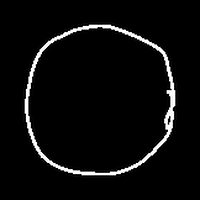
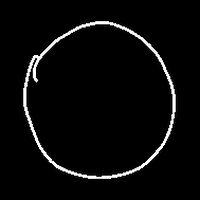
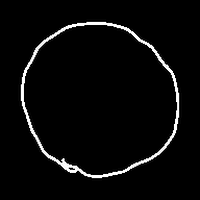
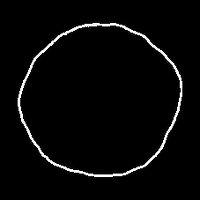
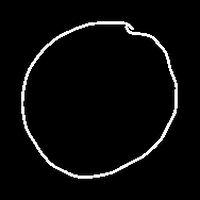
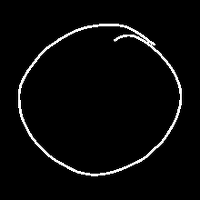
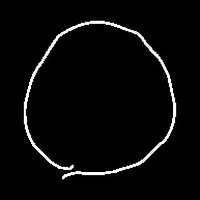
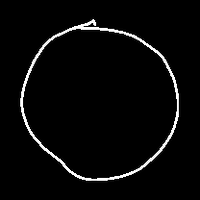
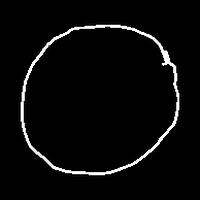
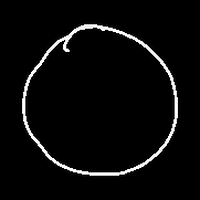
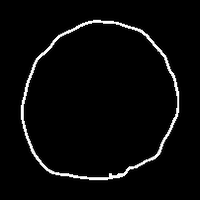
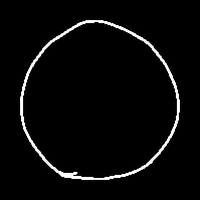
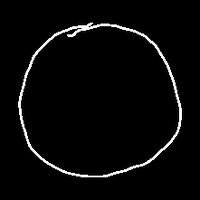
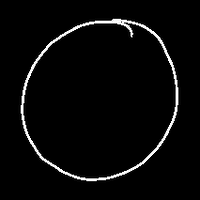
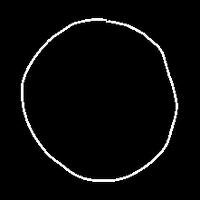
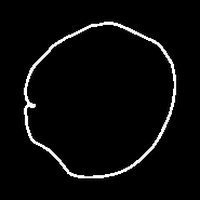
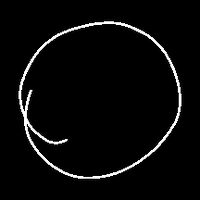
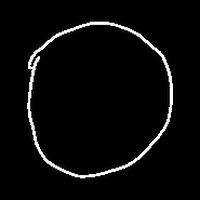
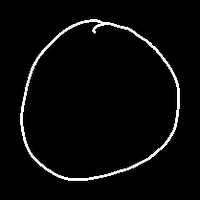
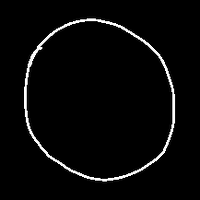
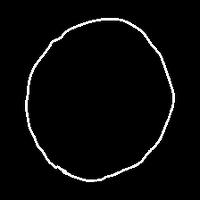
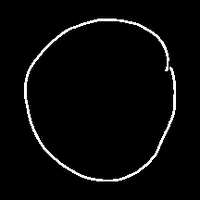
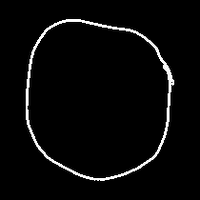
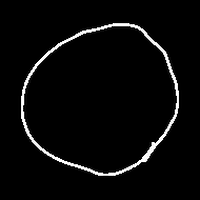
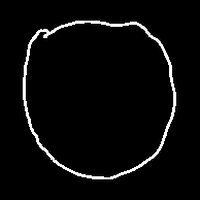
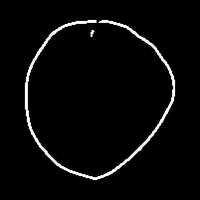
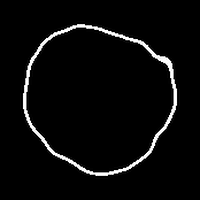
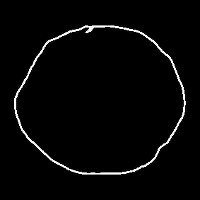

In [18]:

#@title 8️⃣ Create ordered HTML gallery (10 images per row)
html_rows = []
for i, (p,d) in enumerate(zip(sorted_paths, sorted_dists)):
    if i % 10 == 0:
        html_rows.append("<tr>")
    with open(p,'rb') as f: b64 = base64.b64encode(f.read()).decode()
    html_rows.append(
        f"<td style='text-align:center;font-size:10px'>"
        f"<img src='data:image/png;base64,{b64}' width='96'><br>"
        f"{p.name}<br>dist={d:.4f}</td>"
    )
    if i % 10 == 9:
        html_rows.append("</tr>")
if not html_rows[-1].startswith("</tr>"):
    html_rows.append("</tr>")

html_page = f"""
<html><head><meta charset='utf-8'>
<title>{shape_folder} – similarity</title></head>
<body>
<h2>Similarity ranking – {shape_folder}</h2>
<table border=0 cellspacing=4 cellpadding=4>
{''.join(html_rows)}
</table></body></html>
"""

out_path = shape_path / f"{shape_folder}_similarity.html"
with open(out_path,"w") as f: f.write(html_page)
print("▶ HTML gallery written to:", out_path)

display(HTML("<h4>Preview first 30 entries</h4>"+''.join(html_rows[:33])))



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


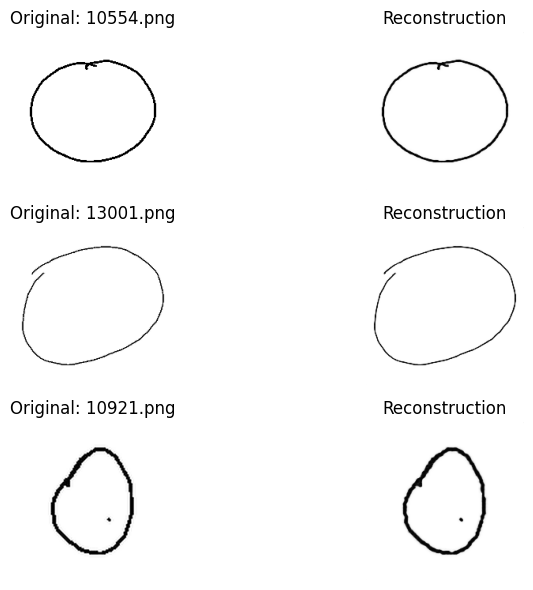

In [19]:
#@title 9️⃣ Reconstruction demo – 3 random drawings
sample_idx = np.random.choice(len(drawing_paths), 3, replace=False)
recons = auto.predict(x_imgs[sample_idx], batch_size=3)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
for i, idx in enumerate(sample_idx):
    # original
    plt.subplot(3,2,2*i+1)
    plt.imshow(x_imgs[idx].squeeze(), cmap='gray')
    plt.axis('off'); plt.title(f"Original: {drawing_paths[idx].name}")
    # reconstruction
    plt.subplot(3,2,2*i+2)
    plt.imshow(recons[i].squeeze(), cmap='gray')
    plt.axis('off'); plt.title("Reconstruction")
plt.tight_layout(); plt.show()
